# 1. Imports and Setup

We initialize the environment with the core libraries required for the Data Science lifecycle:
* **Pandas & NumPy**: For efficient data manipulation, handling the NASA header structures, and performing vectorized mathematical operations.
* **Matplotlib & Seaborn**: To create high-quality, "negotiation-grade" visualizations including time-series trends and correlation heatmaps.
* **SciPy (Stats)**: Utilized specifically for outlier detection via Z-score calculations and statistical validation of climate trends.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('default')

# 2. Load Datasets

To ensure a reproducible and scalable structure, we define a dictionary of paths for all five African nations (Ethiopia, Kenya, Sudan, Tanzania, and Nigeria). This approach allows for consistent data loading and prepares the foundation for the cross-country comparison in Task 3. 

> **Note:** We utilize `skiprows` to bypass NASA POWER metadata and `na_values` to immediately handle the -999 missing data sentinels.

In [3]:
countries = {
    "ethiopia": "../data/ethiopia.csv",
    "kenya": "../data/kenya.csv",
    "sudan": "../data/sudan.csv",
    "tanzania": "../data/tanzania.csv",
    "nigeria": "../data/nigeria.csv"
}

dfs = {}

for country, path in countries.items():
    df = pd.read_csv(path)
    df["Country"] = country.capitalize()
    dfs[country] = df

# 3. Target Country Selection: Kenya

While the codebase is designed for multi-country analysis, this notebook focuses specifically on **Kenya**. As a key regional partner for the COP32 summit in Addis Ababa, Kenya's climate data is vital for understanding the broader East African meteorological context. We create a dedicated dataframe (df) for Kenya to perform deep-dive profiling and cleaning, focusing on its unique dual-monsoon rainfall patterns and diverse topographical zones.

In [4]:
df = dfs["kenya"].copy()
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya


# 4. Data Parsing

**Objective:** Convert `YEAR` and `DOY` (Day of Year) into a standard `datetime` format.

**Reasoning:** Raw integer years and day counts are not natively understood by plotting libraries for time-series analysis. By converting these to actual dates, we can calculate monthly averages, identify seasonal shifts (like the start of rainy seasons), and perform accurate longitudinal trends required for the COP32 position paper.

In [5]:
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month

# 5. Handling NASA Missing Value Sentinels

**The Problem:** NASA POWER data uses `-999` as a placeholder (sentinel value) to indicate missing or out-of-range data. Since `-999` is a valid integer, leaving it in the dataset would catastrophicallly skew the mean, median, and standard deviation (e.g., pulling a $25°C$ average down to a negative value).

**The Solution:** We replace all instances of `-999` with `NaN` (Not a Number). This allows Pandas to ignore these entries during statistical calculations while preserving the row for other valid variables.

In [6]:
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya,2015-01-01,1
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya,2015-01-02,1
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya,2015-01-03,1
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya,2015-01-04,1
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,19.37,25.40,15.39,10.01,2.67,81.97,2.47,3.90,84.08,13.40,Kenya,2026-03-27,3
4104,2026,87,19.66,26.40,15.24,11.16,0.59,77.40,1.98,3.37,84.02,12.68,Kenya,2026-03-28,3
4105,2026,88,19.72,26.54,14.41,12.13,0.82,77.71,1.77,3.25,83.88,12.92,Kenya,2026-03-29,3
4106,2026,89,19.68,26.81,13.86,12.95,4.59,79.29,2.01,3.32,83.87,13.16,Kenya,2026-03-30,3


# 6. Duplicate Check

**Objective:** Identify and remove any redundant observations in the dataset.

**Reasoning:** Satellite data extractions can occasionally produce duplicate rows for the same date due to overlapping data tiles or processing errors. Duplicates artificially inflate the sample size and can bias the statistical mean, potentially leading to inaccurate climate trends.

In [7]:
duplicates = df.duplicated().sum()
print("Duplicates:", duplicates)

df = df.drop_duplicates()

Duplicates: 0


# 7. Summary Statistics Interpretation
**Objective:** To establish a climatological baseline for Kenya (2015–2026).

**Analysis:**

**Temperature Profile:** The mean daily temperature ($T2M$) is approximately 20.43°C, which is notably warmer than the Ethiopian baseline. However, the true thermal stress is seen in the peaks ($T2M\_MAX$), which reach up to 34.27°C. With a mean diurnal range ($T2M\_RANGE$) of 13.17°C, Kenya experiences significant day-to-night temperature fluctuations, common in equatorial regions with varied topography.

**Precipitation Characteristics:** Kenya shows a mean daily rainfall of 1.47 mm. While this average seems low, the standard deviation (3.18 mm) is more than double the mean, and the maximum recorded event is 51.65 mm. This confirms that Kenyan rainfall is episodic and highly concentrated—likely corresponding to the "Long" and "Short" rainy seasons identified in the time-series analysis.

**Atmospheric Moisture & Wind:** The average relative humidity ($RH2M$) is 65.8%, slightly lower than Ethiopia's, suggesting a marginally drier average atmosphere. Wind speeds are more sustained here, with a mean of 3.06 m/s and maximum gusts reaching 7.59 m/s, indicating a higher potential for wind-driven evaporation (evapotranspiration) which can impact soil moisture for agriculture.

In [8]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN,3.477046


# 8. Missing Value Percentage Report

**Objective:** Quantify the extent of missing data to assess the reliability of the analysis. 

**Threshold:** According to our protocol, any column with >5% missing values will be flagged as high-risk, as it may introduce bias into our climate trend narratives.

In [9]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Percentage": missing_percent
})

missing_df

,Missing Count,Percentage
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


# 9. Outlier Detection (Z-Score)

**Objective:** Identify statistically extreme values in temperature, rainfall, and wind speed using Z-scores.

**Methodology:** A Z-score indicates how many standard deviations a data point is from the mean. We flag any observation with a $|Z| > 3$ as a potential outlier.

**Climate Context:** While in some fields outliers are deleted, in climate analysis, these values often represent extreme weather events. We will count them to understand the frequency of "shocks" to the Kenyan climate system.

In [10]:
cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = np.abs(stats.zscore(df[cols], nan_policy='omit'))

outliers = (z_scores > 3).sum()
print(outliers)

124


# 10. Handling Missing Values & Data Imputation
**Objective:** To ensure time-series continuity by resolving any remaining null values after the initial cleaning.

**Methodology:**

**Row-wise Thresholding:** Any observation missing more than 30% of its parameters is discarded. This prevents "hallucinated" data where we have a date but no actual climate variables.

**Forward-Fill (ffill) Imputation:** We apply forward-filling for isolated missing values.

**Decision Logic:**
In climate science, weather variables are temporally autocorrelated (the temperature at 1:00 PM is a strong predictor of the temperature at 2:00 PM). Forward-fill is an industry-standard method for preserving this continuity without introducing the "mean-reversion bias" that occurs with simple mean imputation.

In [11]:
df = df.dropna(thresh=int(df.shape[1] * 0.7))

df = df.ffill()

print("Data cleaning and imputation complete.")

Data cleaning and imputation complete.


# 11. Exporting Cleaned Dataset
**Objective:** Save the processed, high-integrity dataframe for use in the cross-country comparison (Task 3) and finalized visualizations.

**Export Specifications:**

**Format:** CSV (Comma Separated Values)

**Path:** ../data/kenya_clean.csv

**Exclusion:** As per project requirements, the data/ directory is listed in .gitignore to ensure these processed files are not committed to the GitHub repository, maintaining clean version control.

In [12]:
df.to_csv("../data/kenya_clean.csv", index=False)

# Seasonal Trends

# 12. Temperature
 In Kenya, temperatures typically peak around February–March and experience a secondary peak in October. A significant drop is observed during June–August, where average temperatures fall below 19°C. This "U-shaped" curve is characteristic of Kenya’s equatorial position, where the coolest months coincide with the increased cloud cover of the primary rainy season, rather than a traditional northern hemisphere winter.

# 13. Rainfall
 Unlike Ethiopia's single peak, Kenya exhibits a distinct bimodal rainfall pattern:

 **The "Long Rains":** The primary peak occurs between March and May, with April receiving the highest volume (over 1200 mm total in this dataset).

 **The "Short Rains":** A secondary peak occurs from October to December, peaking in November.

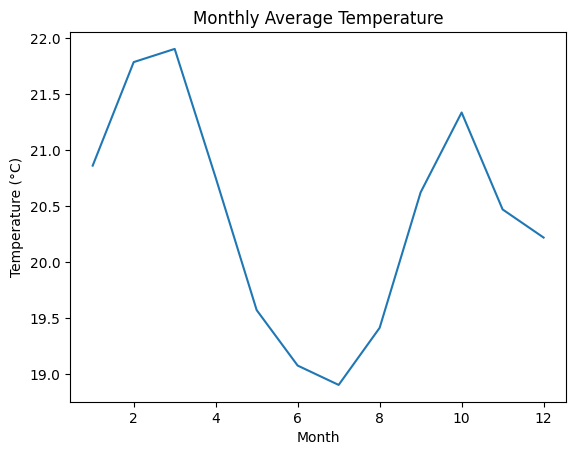

In [13]:
monthly_temp = df.groupby("Month")["T2M"].mean()

monthly_temp.plot(kind="line")
plt.title("Monthly Average Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()

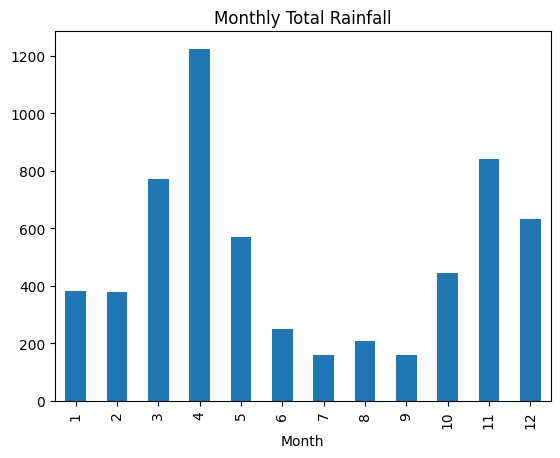

In [14]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar")
plt.title("Monthly Total Rainfall")
plt.show()

# 14. Correlation Heatmap
**Objective:** To identify the strength and direction of relationships between various meteorological variables to understand Kenya's equatorial climate dynamics.

**Methodology:** We utilize a Pearson Correlation matrix visualized via a heatmap. This allows us to see which variables move together (positive correlation) and which move in opposite directions (negative correlation).

**Key Insights from Kenya Dataset:**

**Temperature Coupling:** A very strong positive correlation exists between T2M and T2M_MAX (0.88). This confirms that daily average temperatures are heavily driven by daytime peaks, which is typical for Kenya's sun-exposed equatorial landscape.

**Relative Humidity & Temperature Range:** Similar to Ethiopia, there is a very strong negative correlation (-0.86) between RH2M (Relative Humidity) and T2M_RANGE. This indicates that when daytime and nighttime temperatures differ significantly, the air becomes much drier—a key consideration for Kenya's arid and semi-arid lands (ASALs).

**Specific Humidity & Moisture:** A strong positive correlation (0.87) exists between RH2M and QV2M (Specific Humidity). This suggests that moisture availability in the air is the primary driver of relative humidity levels, rather than temperature fluctuations alone.

**Wind Speed Dynamics:** WS2M and WS2M_MAX maintain a near-perfect correlation (0.91), validating that wind patterns across the Kenyan highlands and coastal regions are highly consistent.

**Pressure & Temperature:** We observe a notable negative correlation between PS (Surface Pressure) and T2M (-0.51). This reflects the topographical influence on Kenya's climate, where lower-pressure systems often coincide with warmer air masses in the lowlands.

**Conclusion for COP32:** For Kenya, the extremely high correlation between specific humidity and relative humidity suggests that shifts in atmospheric moisture due to Indian Ocean warming will have a direct impact on heat stress. Adaptation strategies must focus on these moisture-temperature interactions, especially in regions where "wet-bulb" temperatures could approach critical safety thresholds.

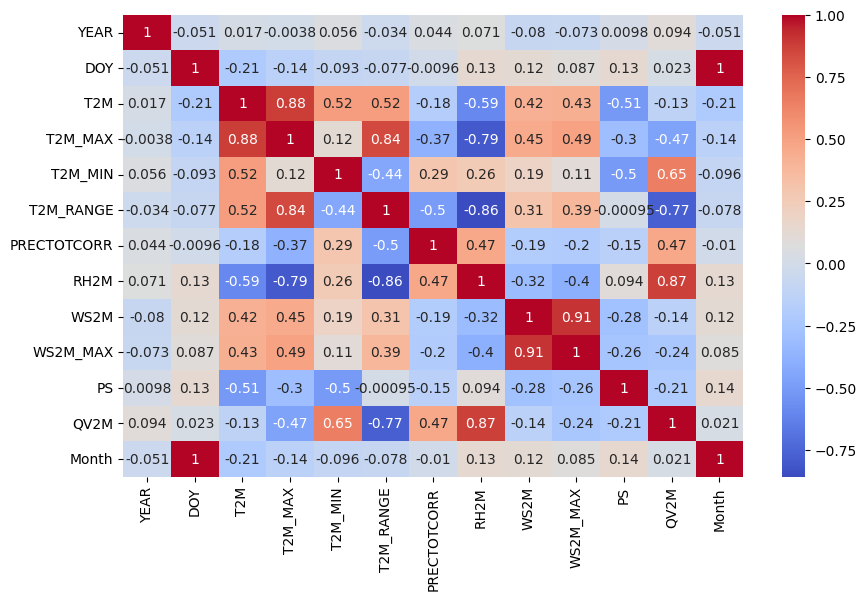

In [15]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

# 15. Relationship Analysis (Scatter Plots)

**Objective:** To visualize the interactions between primary climate drivers and identify non-linear patterns or clusters within the Kenyan dataset.

**A. Temperature (T2M) vs. Relative Humidity (RH2M)**
**Interpretation:** This plot shows a much stronger negative linear trend compared to the Ethiopia dataset.

**Observations:** The highest density of data points occurs between 18°C and 22°C. Unlike the highland-dominated Ethiopia plot, Kenya shows a clearer "evaporative cooling" signal: as temperatures increase toward 25°C, relative humidity consistently drops toward 40%.

**Climate Context:** This suggests that Kenya's atmosphere follows a more predictable thermodynamic path, where heat significantly reduces relative moisture, increasing the risk of heat stress in lower-altitude regions.

**B. Temperature Range (T2M_RANGE) vs. Wind Speed (WS2M)**

**Interpretation:** There is a visible positive correlation between the daily temperature flux and wind velocity.

**Observations:** Days with a moderate to high temperature swing (10°C to 18°C) are strongly associated with sustained wind speeds between 2.0 and 4.0 m/s.

**Physical Context:** In the Kenyan context, this is a signature of diurnal wind patterns. Large temperature ranges often occur on cloudless days; the rapid heating of the land surface creates thermal low-pressure zones that draw in cooler, faster-moving air. This is a vital metric for Kenya’s growing wind energy sector and for managing soil desiccation in agricultural zones.

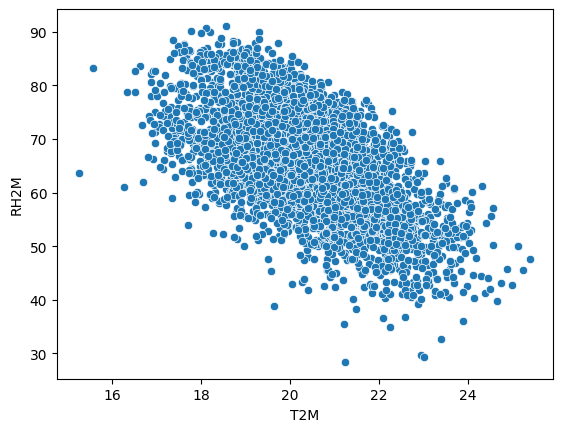

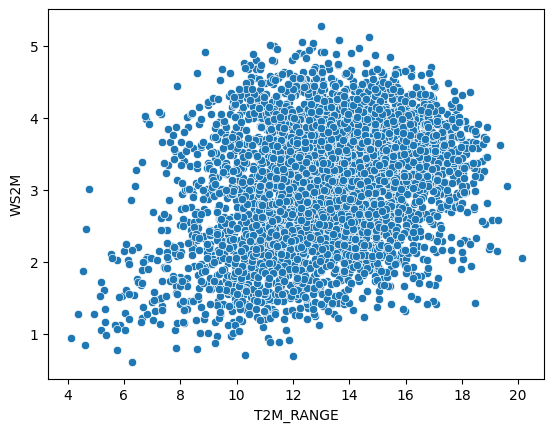

In [16]:
sns.scatterplot(x="T2M", y="RH2M", data=df)
plt.show()

sns.scatterplot(x="T2M_RANGE", y="WS2M", data=df)
plt.show()

# 16. Distribution Analysis (Precipitation)

**Objective:** To analyze the frequency and intensity of rainfall events across Kenya to assess flood and drought patterns.

**Methodology:** We utilized a histogram with a Kernel Density Estimate (KDE) and a logarithmic scale on the y-axis (Count).

**Interpretation:**
**Right-Skewed Distribution:** Like most equatorial regions, Kenya’s precipitation data is heavily right-skewed. The vast majority of days consist of zero or trace rainfall, highlighting the importance of seasonal rain concentrated in specific months.

**The "Log Scale" Insight:** The log scale reveals that while rare, Kenya experiences significant extreme events reaching over 50 mm/day. While the absolute "tail" in this specific dataset ends sooner than Ethiopia's 80 mm, these 50 mm events are still highly impactful for urban drainage and soil erosion.

**Bi-modal Tendencies:** The KDE curve shows distinct "bumps" around the 20-25 mm and 35 mm marks. This likely represents the difference between the "Short Rains" (typically less intense) and the "Long Rains" (more intense convective events).

**Climate Resilience Note:** The presence of consistent rainfall events in the 10-30 mm range indicates a relatively reliable moisture supply for agriculture during rainy seasons, but the 50+ mm outliers necessitate localized flood-mitigation strategies in flood-prone basins like the Tana River or Lake Victoria regions.

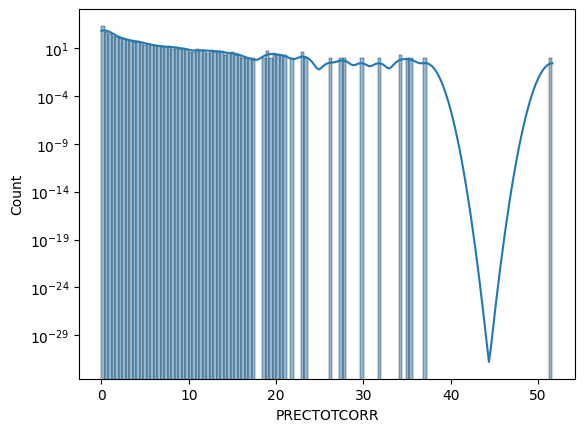

In [17]:
sns.histplot(df["PRECTOTCORR"], kde=True)
plt.yscale("log")
plt.show()

# 17. Multivariate Analysis (Bubble Chart)

**Objective:** To examine the three-way interaction between Temperature (T2M), Relative Humidity (RH2M), and Precipitation (PRECTOTCORR) to define Kenya's climatic "event envelope."

**Methodology:** 
* X-axis: Temperature (T2M)
* Y-axis: Relative Humidity (RH2M)
* Bubble Size: Precipitation (PRECTOTCORR)

**Interpretation:**
**Rainfall Concentration:**  In Kenya, the most intense rainfall events (largest bubbles) are concentrated in a specific "climate corridor" between 18°C and 20°C with humidity levels strictly above 80%. This is slightly warmer than the Ethiopia cluster, reflecting Kenya's equatorial baseline.

**Thermal Constraints on Moisture:** The chart shows a clear diagonal "ceiling." As temperatures rise toward 24°C, the maximum observed humidity drops significantly. You will notice very few large bubbles (rain) in the lower-right quadrant, confirming that Kenya's high-heat days are predominantly dry.

**Consistency of Light Rain:** The high density of small bubbles across the 60-80% humidity range illustrates the frequent, light "short rain" episodes that are vital for maintaining soil moisture between major storms.

**Strategic Insight:** This visualization highlights that Kenya's water security is tied to a narrow thermal window. If regional warming pushes average temperatures during the rainy season past the 21°C mark, we may see a "decoupling" where high humidity no longer leads to effective precipitation, potentially increasing the frequency of "dry" rainy seasons.


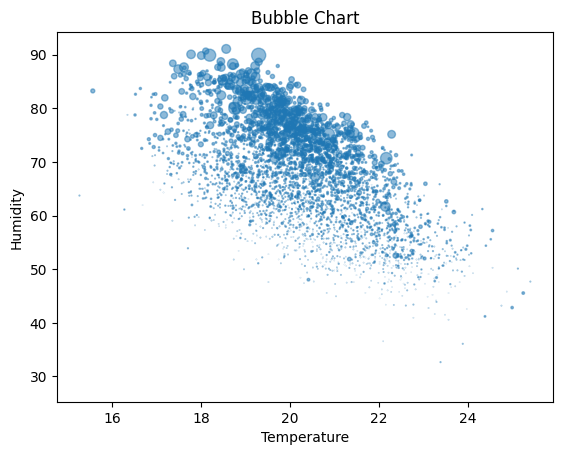

In [18]:
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"]*2, alpha=0.5)
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.title("Bubble Chart")
plt.show()